# Entrega proyecto
#### Juan Daniel Traslaviña - Johany Florez

This notebook contains the full reinforcement-learning project:

1. **Ambiente** – Ambiente de grid world, con llave, puerta, pelota y meta final.
2. **Agente** – un agente de Q-Learning agent con selección de acciones ε-greedy.
3. **Entrenamiento y evaluación** – Configuración de hiperparámetros, ciclo de aprendizaje, curva de premio y demostración greedy.
4. **Visualización** – matplotlib learning curve, policy map, and animated demonstration.
5. **Guardado y Carga** – Persiste y restaura Q-tabla como JSON.

---
## 1. Ambiente

Ambiente de grid world:

```
# # # # # # # # # # #
#         #   E      #
# K        #          #
#         #          #
# S       #          #
#       B D          #
# # # # # # # # # # #
```

- **S** – Inicio
- **E** – Salida / meta
- **K** – llave (Debe ser recogida)
- **D** – puerta (Se abre con la llave)
- **B** – Pelota (Obstaculo)

In [17]:
class Environment:

    def __init__(self):
        self.steps = 50  # iteraciones
        self.project_board()
        self.agent = (4, 1)  # posicion inicial
        self.goal = (1, 7)   # posicion de la meta — celda 'E' 
        self.carrying = None  # Objeto que el agente esta cargando (ejemplo: 'K')
        self.picked_up = set()  # items recogidos al menos una vez (solo para premio)
        self.ball_pos = (5, 4)  # posicion de la pelota para el estado

    def project_board(self):
        self.board = [
            ['#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#'],
            ['#', ' ', ' ', ' ', ' ', '#', ' ', 'E', ' ', ' ', '#'],
            ['#', 'K', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' ', '#'],
            ['#', ' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' ', '#'],
            ['#', 'S', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' ', '#'],
            ['#', ' ', ' ', ' ', 'B', 'D', ' ', ' ', ' ', ' ', '#'],
            ['#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#']
        ]

    # ------------------------------------------------------------------
    # Utilidades
    # ------------------------------------------------------------------

    def _cell_is_passable(self, row, col):
        """Retorna verdadero si es una celda a la que el agente se puede mover"""
        cell = self.board[row][col]
        if cell == '#':
            return False
        if cell == 'B':
            return False          # Pelota SIEMPRE bloquea movimiento
        if cell == 'D':           # Puerta bloquea movimiento (Si no tiene llave)
            return self.carrying == 'K'
        return True


    def get_state(self):
        """Estado compuesto: (Posicion, Cargando).
        Se usa para que la Q-tabla tenga los estados optimos."""
        return (self.agent, self.carrying, self.ball_pos)

    def reset(self):
        """Restaura el ambiente"""
        self.steps = 50
        self.project_board()
        self.agent = (4, 1)
        self.carrying = None
        self.picked_up = set()
        self.ball_pos = (5, 4)

    def is_done(self):
        """Episodio termina si el agente llega a la meta o queda sin pasos"""
        return self.agent == self.goal or self.steps <= 0

    # ------------------------------------------------------------------
    # Acciones
    # ------------------------------------------------------------------

    DIRECTIONS = {
        'up':    (-1,  0),
        'down':  ( 1,  0),
        'left':  ( 0, -1),
        'right': ( 0,  1),
    }

    def get_possible_actions(self, state=None):
        """Return the list of valid action strings from the current (or given) state."""
        if state is None:
            state = self.agent

        actions = []
        for direction, (dr, dc) in self.DIRECTIONS.items():
            nr, nc = state[0] + dr, state[1] + dc
            if 0 <= nr < len(self.board) and 0 <= nc < len(self.board[0]):
                if self._cell_is_passable(nr, nc):
                    actions.append(direction)

        # Agente recoge objeto en celda adyacente
        if self.carrying is None:
            for direction, (dr, dc) in self.DIRECTIONS.items():
                nr, nc = state[0] + dr, state[1] + dc
                if 0 <= nr < len(self.board) and 0 <= nc < len(self.board[0]):
                    adj_cell = self.board[nr][nc]
                    if adj_cell in ('K', 'B'):
                        actions.append(f'pickup_{direction}')

        # Suelta objeto en celda adyacente
        if self.carrying is not None:
            for direction, (dr, dc) in self.DIRECTIONS.items():
                nr, nc = state[0] + dr, state[1] + dc
                if 0 <= nr < len(self.board) and 0 <= nc < len(self.board[0]):
                    if self.board[nr][nc] == ' ':
                        actions.append(f'drop_{direction}')

        return actions


    def do_action(self, action):

        reward = -1         
        row, col = self.agent

        if action in self.DIRECTIONS:
            # Sumar la posicion actual con la cardinalidad destino
            dr, dc = self.DIRECTIONS[action]
            nr, nc = row + dr, col + dc

            if not (0 <= nr < len(self.board) and 0 <= nc < len(self.board[0])):
                return self.agent, reward, self.is_done()

            cell = self.board[nr][nc]

            if cell == '#':
                reward -= 5
                return self.agent, reward, self.is_done()

            # Pelota SIEMPRE bloquea movimiento
            if cell == 'B':
                reward -= 5
                return self.agent, reward, self.is_done()

            if cell == 'D':
                if self.carrying != 'K':
                    reward -= 5
                    return self.agent, reward, self.is_done()
                # Usar llave para la puerta
                self.carrying = None
                self.board[nr][nc] = ' '
                reward += 50

            if self.board[row][col] == 'S':
                self.board[row][col] = ' '
            self.agent = (nr, nc)

            if self.agent == self.goal:
                reward += 100

        # Recoger de manera direccional
        elif action.startswith('pickup_'):
            direction = action[len('pickup_'):]
            if direction in self.DIRECTIONS:
                dr, dc = self.DIRECTIONS[direction]
                nr, nc = row + dr, col + dc
                if 0 <= nr < len(self.board) and 0 <= nc < len(self.board[0]):
                    cell = self.board[nr][nc]
                    if cell == 'K':
                        if 'K' not in self.picked_up:
                            reward += 30
                            self.picked_up.add('K')
                        else:
                            reward -= 2  # penalidad por re-recoger
                        self.carrying = cell
                        self.board[nr][nc] = ' '
                    elif cell == 'B':
                        if 'B' not in self.picked_up:
                            reward += 10
                            self.picked_up.add('B')
                        else:
                            reward -= 2  # penalidad por re-recoger
                        self.carrying = cell
                        self.board[nr][nc] = ' '
                        self.ball_pos = None  # pelota siendo cargada

        # Soltar de manera direccional
        elif action.startswith('drop_'):
            direction = action[len('drop_'):]
            if direction in self.DIRECTIONS:
                dr, dc = self.DIRECTIONS[direction]
                nr, nc = row + dr, col + dc
                if (0 <= nr < len(self.board) and 0 <= nc < len(self.board[0])
                        and self.board[nr][nc] == ' ' and self.carrying is not None):
                    if self.carrying == 'B':
                        self.ball_pos = (nr, nc)
                    self.board[nr][nc] = self.carrying
                    self.carrying = None

        self.steps -= 1
        done = self.is_done()
        return self.agent, reward, done

    # ------------------------------------------------------------------
    # Display
    # ------------------------------------------------------------------

    def render(self):
        for r, row in enumerate(self.board):
            line = ''
            for c, cell in enumerate(row):
                if (r, c) == self.agent:
                    line += 'A '
                else:
                    line += cell + ' '
            print(line)
        print(f"Steps left: {self.steps}  |  Carrying: {self.carrying or 'nothing'}")
        print()

---
## 2. Agente

Agente de Q-Learning:
- Exploracion ε-greedy
- Actualizacion de Q tabla: `Q(s,a) = (1−α)·Q(s,a) + α·[r + γ·max Q(s',a')]`
- Epsilon decay (×0.9 por episode, piso de 0.01)
- Guardado y cargado JSON

In [18]:
import random
import json
import ast


class QLearning:

    def __init__(self, env, epsilon=0.9, gamma=0.9, alpha=0.5):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha
        self.qtable: dict[tuple, float] = {}  # (state, action) -> Q-value

    def get_value(self, state: tuple, action: str) -> float:
        return self.qtable.get((state, action), 0.0)

    # ------------------------------------------------------------------
    # Seleccion de accion
    # ------------------------------------------------------------------

    def choose_action(self, state: tuple) -> str:
        actions = self.env.get_possible_actions(self.env.agent)
        if not actions:
            return None

        if random.random() < self.epsilon:
            return random.choice(actions)

        return self.best_action(state)

    def best_action(self, state: tuple) -> str:
        actions = self.env.get_possible_actions(state[0]) 
        if not actions:
            return ""

        max_val = max(self.get_value(state, a) for a in actions)
        best = [a for a in actions if self.get_value(state, a) == max_val]
        return random.choice(best)


    def update_values(self, state: tuple, action: str,
                      next_state: tuple, reward: float) -> None:
        """Q(s,a) = (1-a)*Q(s,a) + a*[r + g*max_a' Q(s',a')]"""
        next_actions = self.env.get_possible_actions(next_state[0])
        if next_actions:
            max_next = max(self.get_value(next_state, a) for a in next_actions)
        else:
            max_next = 0.0

        old = self.get_value(state, action)
        new = (1 - self.alpha) * old + self.alpha * (reward + self.gamma * max_next)
        self.qtable[(state, action)] = new



    def save_qtable(self, path: str = 'qtable.json') -> None:
        data = {
            'epsilon': self.epsilon,
            'gamma': self.gamma,
            'alpha': self.alpha,
            'qtable': {str(k): v for k, v in self.qtable.items()}
        }
        with open(path, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"Q-table saved to {path}  ({len(self.qtable)} entries)")

    def load_qtable(self, path: str = 'qtable.json') -> None:
        with open(path, 'r') as f:
            data = json.load(f)
        self.epsilon = data.get('epsilon', self.epsilon)
        self.gamma   = data.get('gamma',   self.gamma)
        self.alpha   = data.get('alpha',   self.alpha)
        self.qtable  = {ast.literal_eval(k): v for k, v in data['qtable'].items()}
        print(f"Q-table loaded from {path}  ({len(self.qtable)} entries, eps={self.epsilon:.4f})")

    # ------------------------------------------------------------------
    # Pasos y ejecucion
    # ------------------------------------------------------------------

    def step(self, action: str):
        old_pos = self.env.agent
        new_pos, reward, done = self.env.do_action(action)
        next_state = self.env.get_state()

        info = (f"pos {old_pos} --[{action}]--> {new_pos}  "
                f"r={reward}  carrying={self.env.carrying}  done={done}")
        return next_state, reward, done, info

    def run(self, episodes: int) -> dict:
        rewards_per_episode = []

        for ep in range(episodes):
            self.env.reset()
            state = self.env.get_state()
            done = False
            total_reward = 0

            while not done:
                action = self.choose_action(state)
                if action is None:
                    break

                next_state, reward, done, info = self.step(action)
                self.update_values(state, action, next_state, reward)

                state = next_state
                total_reward += reward

            rewards_per_episode.append(total_reward)

            # Epsilon decay (10 % reduction per episode, floor = 0.01)
            if self.epsilon > 0.01:
                self.epsilon *= 0.955
                if self.epsilon < 0.01:
                    self.epsilon = 0.01

        return self.qtable, rewards_per_episode

---
## 3. Training & Evaluation

### 3.1 Hyperparameters

In [19]:
EPISODES = 10000
EPSILON  = 0.9      # initial exploration rate
GAMMA    = 0.9      # discount factor
ALPHA    = 0.5      # learning rate

### 3.2 Training

In [20]:
def train():
    env   = Environment()
    agent = QLearning(env, epsilon=EPSILON, gamma=GAMMA, alpha=ALPHA)

    print("=" * 55)
    print(f"  Episodios : {EPISODES}")
    print(f"  eps={EPSILON}   gamma={GAMMA}   alpha={ALPHA}")
    print(f"  Tablero    : {len(env.board)}x{len(env.board[0])}")
    print("=" * 55)
    print()

    qtable, rewards = agent.run(EPISODES)

    print(f"Entrenamiento completo - {EPISODES} episodios")
    print(f"  Final eps      : {agent.epsilon:.4f}")
    print(f"  entradas Q-tabla: {len(qtable)}")
    print()

    return agent, rewards

### 3.3 Reward Curve (ASCII)

In [21]:
def show_reward_curve(rewards: list[float]):
    n = len(rewards)
    bucket = max(1, n // 10)
    print("-- Premio promedio por bucket --")
    for i in range(0, n, bucket):
        chunk = rewards[i:i + bucket]
        avg = sum(chunk) / len(chunk)
        bar = "#" * max(0, int((avg + 20) / 2))
        print(f"  ep {i:>4}-{i + len(chunk) - 1:<4}  avg {avg:>7.1f}  {bar}")
    print()

### 3.4 Greedy Demonstration (text)

In [22]:
def demonstrate(agent: QLearning, max_steps: int = 30):
    env = agent.env
    env.reset()
    agent.epsilon = 0.0

    print("-- Demostración Greedy --")
    env.render()

    total_reward = 0
    for step in range(1, max_steps + 1):
        state = env.get_state()
        action = agent.best_action(state)
        if not action:
            print("Sin acciones válidas -- atascado")
            break

        next_state, reward, done, info = agent.step(action)
        total_reward += reward

        print(f"Step {step}: {info}")
        env.render()

        if done:
            if env.agent == env.goal:
                print("** Agente llegó a la meta! **")
            else:
                print("-- Sin pasos. --")
            break

    print(f"Premiación total: {total_reward}")

### 3.5 Run Everything

In [23]:
agent, rewards = train()
show_reward_curve(rewards)
demonstrate(agent)

  Episodios : 10000
  eps=0.9   gamma=0.9   alpha=0.5
  Tablero    : 7x11

Entrenamiento completo - 10000 episodios
  Final eps      : 0.0100
  entradas Q-tabla: 4586

-- Premio promedio por bucket --
  ep    0-999   avg    63.5  #########################################
  ep 1000-1999  avg   151.6  #####################################################################################
  ep 2000-2999  avg   143.2  #################################################################################
  ep 3000-3999  avg   153.6  ######################################################################################
  ep 4000-4999  avg   162.1  ###########################################################################################
  ep 5000-5999  avg   165.2  ############################################################################################
  ep 6000-6999  avg   160.2  ##########################################################################################
  ep 7000-7999  avg   1

---
## 4. Visualization

Matplotlib-based visualizations:
- **Learning curve** – reward per episode with rolling average
- **Policy map** – grid colored by cell type, with arrows showing the best action and Q-values (one map per carrying state)
- **Animated demonstration** – step-by-step greedy playback rendered on the grid

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from IPython.display import clear_output, display
import time

# ── Color palette ────────────────────────────────────────────────────
CELL_COLORS = {
    '#': '#1B1B2F',    # walls  – deep navy
    ' ': '#F0EDE5',    # empty  – warm cream
    'S': '#FFD166',    # start  – golden yellow
    'E': '#06D6A0',    # goal   – emerald green
    'K': '#EF476F',    # key    – coral
    'D': '#9C6644',    # door   – warm brown
    'B': '#118AB2',    # ball   – ocean blue
}

ARROW_DXY = {
    'up':    ( 0.0,  0.25),
    'down':  ( 0.0, -0.25),
    'left':  (-0.25, 0.0),
    'right': ( 0.25, 0.0),
}


def _original_board():
    return [
        ['#','#','#','#','#','#','#','#','#','#','#'],
        ['#',' ',' ',' ',' ','#',' ','E',' ',' ','#'],
        ['#','K',' ',' ',' ','#',' ',' ',' ',' ','#'],
        ['#',' ',' ',' ',' ','#',' ',' ',' ',' ','#'],
        ['#','S',' ',' ',' ','#',' ',' ',' ',' ','#'],
        ['#',' ',' ',' ','B','D',' ',' ',' ',' ','#'],
        ['#','#','#','#','#','#','#','#','#','#','#'],
    ]

### 4.1 Learning Curve

In [25]:
def plot_reward_curve(rewards):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(rewards, alpha=0.25, color='#118AB2', linewidth=0.5, label='por episodio')

    # Rolling average
    w = max(1, len(rewards) // 20)
    rolling = []
    for i in range(len(rewards)):
        lo = max(0, i - w + 1)
        rolling.append(sum(rewards[lo:i+1]) / (i - lo + 1))
    ax.plot(rolling, color='#EF476F', linewidth=2, label=f'avg (w={w})')

    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel('premio total', fontsize=12)
    ax.set_title('Curva de aprendizaje', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

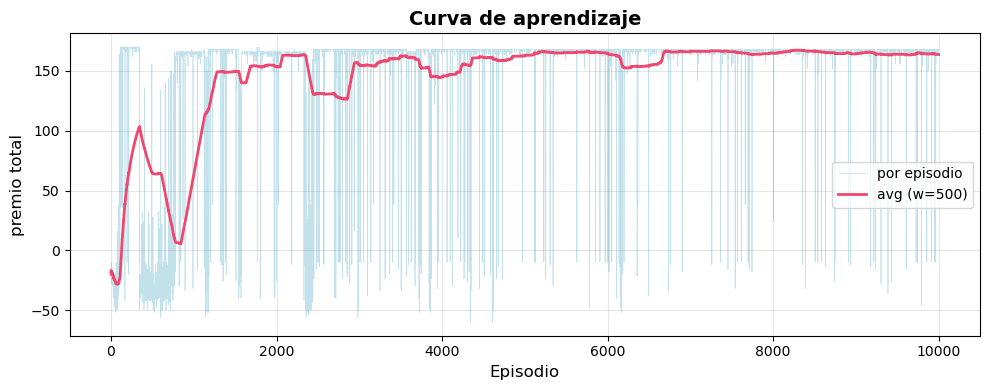

In [26]:
plot_reward_curve(rewards)

### 4.2 Policy Map

Shows the best action (arrow) and Q-value for every visited cell.
A separate map is drawn for each *carrying state* because the optimal
policy changes depending on what the agent holds.

In [27]:
def plot_policy(qtable):
    original = _original_board()
    nrows = len(original)
    ncols = len(original[0])

    sa = defaultdict(dict)
    for (state, action), value in qtable.items():
        sa[state][action] = value

    carrying_states = sorted(set(s[1] for s in sa), key=lambda x: str(x))
    n = len(carrying_states)

    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]

    for ax, carrying in zip(axes, carrying_states):
        ax.set_title(f"Carrying: {carrying or 'nothing'}",
                     fontsize=14, fontweight='bold', pad=12)

        for r in range(nrows):
            for c in range(ncols):
                cell = original[r][c]
                color = CELL_COLORS.get(cell, '#F0EDE5')
                y = nrows - r - 1  

                ax.add_patch(mpatches.FancyBboxPatch(
                    (c + 0.02, y + 0.02), 0.96, 0.96,
                    boxstyle='round,pad=0.02',
                    facecolor=color, edgecolor='#2D2D33', linewidth=1.2
                ))

                if cell in ('S', 'E', 'K', 'D', 'B'):
                    tc = 'white' if cell in ('#', 'D') else '#333'
                    ax.text(c + 0.5, y + 0.82, cell,
                            ha='center', va='center', fontsize=11,
                            fontweight='bold', color=tc)

                state = ((r, c), carrying)
                if state in sa:
                    actions = sa[state]
                    best_a = max(actions, key=actions.get)
                    best_v = actions[best_a]

                    ax.text(c + 0.5, y + 0.52, f"{best_v:.1f}",
                            ha='center', va='center', fontsize=7, color='#666')

                    if best_a in ARROW_DXY:
                        dx, dy = ARROW_DXY[best_a]
                        ax.annotate('',
                            xy=(c + 0.5 + dx, y + 0.22 + dy),
                            xytext=(c + 0.5, y + 0.22),
                            arrowprops=dict(arrowstyle='->', color='#E63946', lw=2))
                    elif best_a == 'pickup':
                        ax.text(c + 0.5, y + 0.18, 'PICK',
                                ha='center', va='center', fontsize=6,
                                fontweight='bold', color='#E63946')
                    elif best_a == 'drop':
                        ax.text(c + 0.5, y + 0.18, 'DROP',
                                ha='center', va='center', fontsize=6,
                                fontweight='bold', color='#E63946')

        ax.set_xlim(0, ncols)
        ax.set_ylim(0, nrows)
        ax.set_aspect('equal')
        ax.axis('off')

    fig.suptitle('Learned Policy Map', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

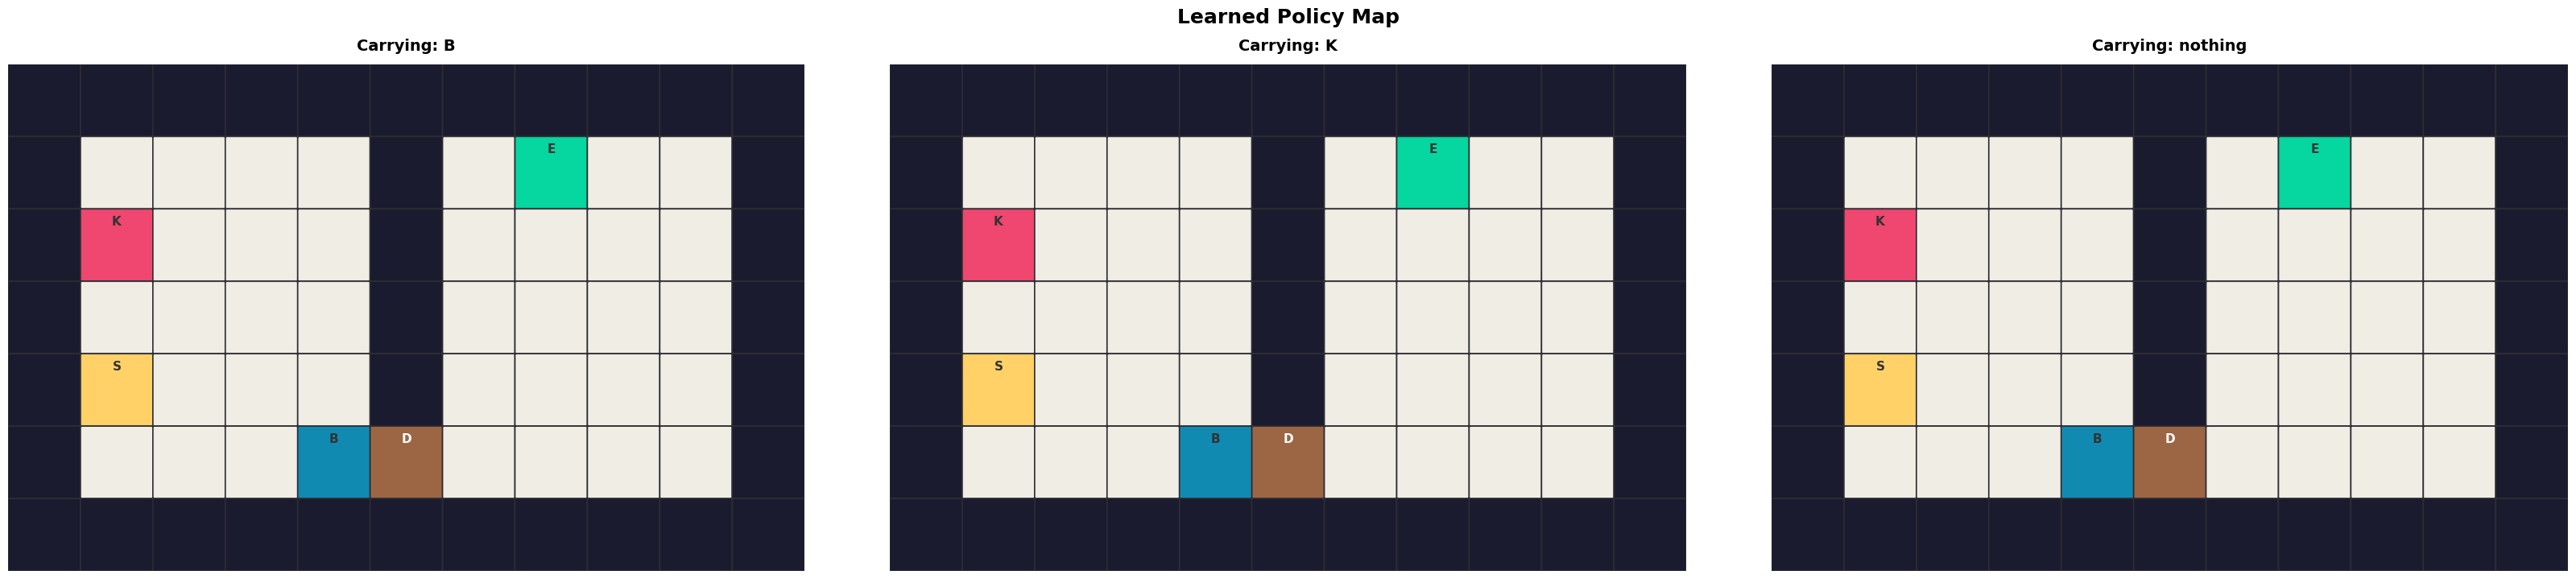

In [28]:
plot_policy(agent.qtable)

### 4.3 Animated Demonstration

Runs a greedy episode and renders each step on the grid in real-time.
The agent's path is shown as a fading trail of dots.

In [29]:
def visual_demonstrate(agent, max_steps=30, delay=0.5):
    """Demostración paso por paso con matplotlib"""
    env = agent.env
    env.reset()
    saved_eps = agent.epsilon
    agent.epsilon = 0.0

    nrows = len(env.board)
    ncols = len(env.board[0])
    original = _original_board()

    total_reward = 0
    path = [env.agent]
    actions_taken = []

    def draw_frame(step_num, last_action=None):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 7))

        for r in range(nrows):
            for c in range(ncols):
                cell = env.board[r][c]
                y = nrows - r - 1

                if cell == '#':
                    color = CELL_COLORS['#']
                elif (r, c) == env.agent:
                    color = '#E63946'
                else:
                    color = CELL_COLORS.get(cell, CELL_COLORS[' '])

                ax.add_patch(mpatches.FancyBboxPatch(
                    (c + 0.02, y + 0.02), 0.96, 0.96,
                    boxstyle='round,pad=0.02',
                    facecolor=color, edgecolor='#2D2D33', linewidth=1.2
                ))

                if (r, c) == env.agent:
                    ax.text(c + 0.5, y + 0.5, 'A',
                            ha='center', va='center', fontsize=20,
                            fontweight='bold', color='white')
                elif cell in ('E', 'K', 'D', 'B', 'S'):
                    tc = 'white' if cell == 'D' else '#333'
                    ax.text(c + 0.5, y + 0.5, cell,
                            ha='center', va='center', fontsize=14,
                            fontweight='bold', color=tc)

        # Path trail
        for i, (pr, pc) in enumerate(path[:-1]):
            py = nrows - pr - 1
            a = 0.15 + 0.65 * (i / max(len(path) - 1, 1))
            ax.plot(pc + 0.5, py + 0.5, 'o',
                    color='#E63946', alpha=min(a, 0.85), markersize=6)

        ax.set_xlim(0, ncols)
        ax.set_ylim(0, nrows)
        ax.set_aspect('equal')
        ax.axis('off')

        carrying = env.carrying or 'nothing'
        act_str = f"  |  Action: {last_action}" if last_action else ""
        title = (f"Step {step_num}  |  Reward: {total_reward:.0f}"
                 f"  |  Carrying: {carrying}{act_str}")
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

        plt.tight_layout()
        plt.show()

    # Initial frame
    draw_frame(0)
    time.sleep(delay)

    for step in range(1, max_steps + 1):
        state = env.get_state()
        action = agent.best_action(state)
        if not action:
            print("Sin acciones validas - Atascado!")
            break

        _, reward, done, _ = agent.step(action)
        total_reward += reward
        path.append(env.agent)
        actions_taken.append(action)

        draw_frame(step, action)

        if done:
            if env.agent == env.goal:
                print(f"\n**Agente llegó a la meta en {step} pasos!  Premio total: {total_reward} **")
            else:
                print(f"\n-- Agente se quedó sin pasos.  Premio total: {total_reward} --")
            break

        time.sleep(delay)

    agent.epsilon = saved_eps

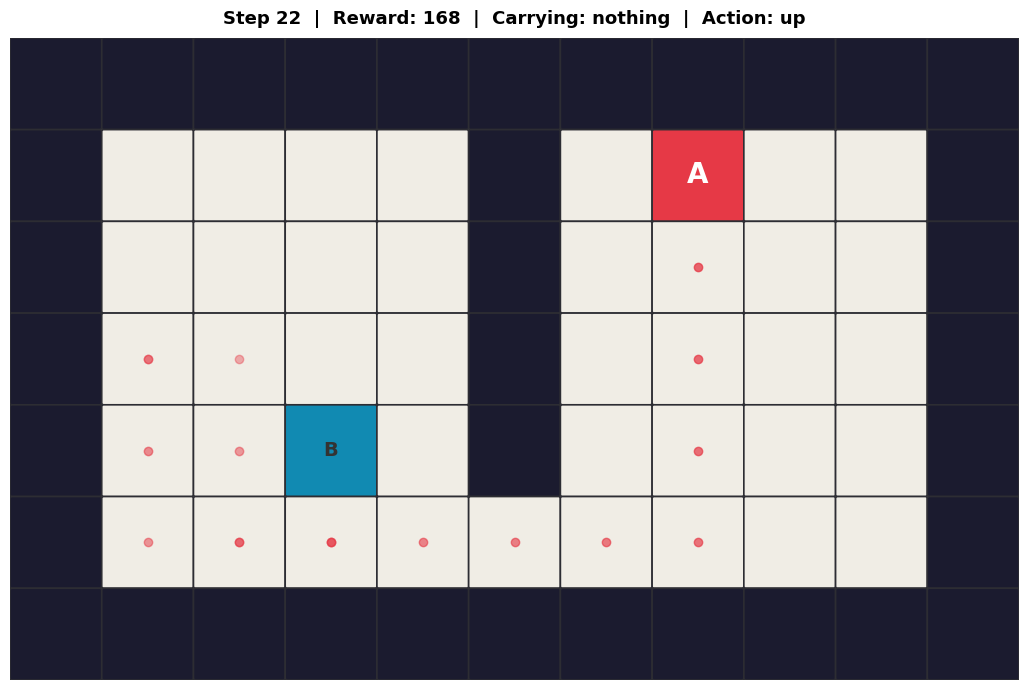


**Agente llegó a la meta en 22 pasos!  Premio total: 168 **


In [33]:
visual_demonstrate(agent, delay=0.4)

---
## 5. Guardar / Cargar Q tabla

### 5.1 Guardado de Q tabla

In [31]:
agent.save_qtable('qtable.json')

Q-table saved to qtable.json  (4586 entries)


### 5.2 Cargado de Q tabla

Create a fresh agent and load the saved weights — no retraining needed.
Crea un agente y cargo los pesos guardados, sin necesidad de reentrenar

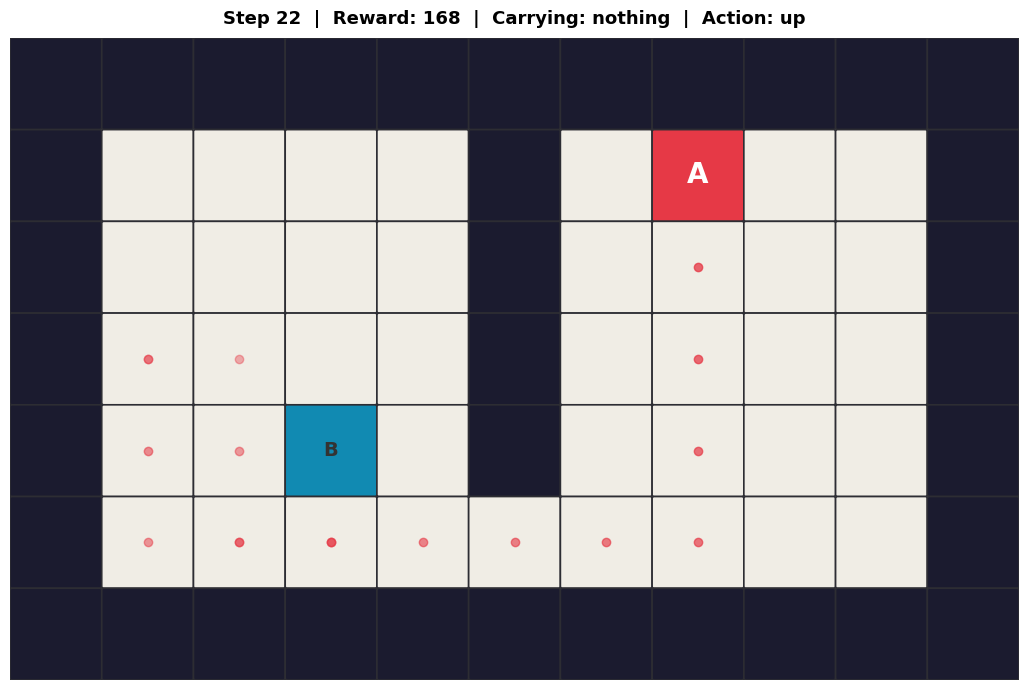


**Agente llegó a la meta en 22 pasos!  Premio total: 168 **


In [32]:
env2 = Environment()
agent2 = QLearning(env2)
agent2.load_qtable('qtable.json')

visual_demonstrate(agent2, delay=0.4)